In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predicting-stock-trends-rise-or-fall/sample_submission.csv
/kaggle/input/predicting-stock-trends-rise-or-fall/train.csv
/kaggle/input/predicting-stock-trends-rise-or-fall/test.csv


# Load Data

In [2]:
data_path = dirname

In [3]:
df_train = pd.read_csv(f"{data_path}/train.csv", parse_dates=["Date"])
df_test = pd.read_csv(f"{data_path}/test.csv", parse_dates=["Date"])
df_submission = pd.read_csv(f"{data_path}/sample_submission.csv")

In [4]:
# Determine when data will be used for training
TRAIN_FROM = "2024-01-01"

In [5]:
df_train = df_train[df_train["Date"] >= TRAIN_FROM]

In [6]:
df_train.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
20119055,ticker_4102,2024-01-02,67.510002,71.775002,66.800003,71.639999,349000.0,0.0,0.0
20119056,ticker_178,2024-01-02,69.650002,70.480003,69.639999,70.459999,774100.0,0.0,0.0
20119057,ticker_1838,2024-01-02,8.830000,9.240000,8.700000,9.000000,1306500.0,0.0,0.0
20119058,ticker_2860,2024-01-02,2.700000,2.705000,2.625000,2.640000,443000.0,0.0,0.0
20119059,ticker_4514,2024-01-02,15.760000,16.299999,15.410000,16.280001,28700.0,0.0,0.0


In [7]:
df_train.tail()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
21033517,ticker_2098,2024-09-23,15.230000,15.230000,14.690000,14.780000,63400.0,0.0,0.0
21033518,ticker_3748,2024-09-23,24.700001,24.768400,24.510000,24.570000,31208.0,0.0,0.0
21033519,ticker_2615,2024-09-23,11.090000,11.150000,10.960000,11.090000,1014300.0,0.0,0.0
21033520,ticker_4765,2024-09-23,25.200001,25.202999,25.129999,25.134001,4500.0,0.0,0.0
21033521,ticker_4658,2024-09-23,0.281000,0.290000,0.264000,0.270000,272200.0,0.0,0.0


In [8]:
df_train.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,914467,914467.000000,914467.000000,914467.000000,914467.000000,9.144670e+05,914467.0,914467.0
mean,2024-05-13 01:37:22.154610176,34.308120,34.761675,33.848394,34.301863,1.349070e+06,0.0,0.0
min,2024-01-02 00:00:00,0.010000,0.079000,0.010000,0.078510,0.000000e+00,0.0,0.0
25%,2024-03-07 00:00:00,5.640000,5.790000,5.495000,5.630000,4.975050e+04,0.0,0.0
50%,2024-05-13 00:00:00,15.750000,15.990000,15.510000,15.740000,2.548000e+05,0.0,0.0
75%,2024-07-19 00:00:00,37.200001,37.745499,36.650002,37.189999,9.530000e+05,0.0,0.0
max,2024-09-23 00:00:00,429.339996,431.033997,422.000000,428.850006,5.617574e+08,0.0,0.0
std,NaN,51.048017,51.625709,50.457484,51.050060,5.237972e+06,0.0,0.0


In [9]:
df_train.isnull().sum()

Ticker          0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

# AD Fuller Test

In [10]:
ticker = "ticker_1"

In [11]:
df_t = df_train[df_train["Ticker"] == ticker].copy()

In [12]:
df_t.set_index("Date", inplace=True)

In [13]:
df_t.index = pd.DatetimeIndex(df_t.index).to_period("D")

In [14]:
df_t = df_t.sort_index()

In [15]:
df_t.head()

,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2024-01-02,ticker_1,90.699997,92.550003,90.559998,92.410004,1806900.0,0.0,0.0
2024-01-03,ticker_1,92.610001,93.080002,92.120003,93.000000,2014300.0,0.0,0.0
2024-01-04,ticker_1,93.489998,94.000000,92.900002,93.250000,1727100.0,0.0,0.0
2024-01-05,ticker_1,93.050003,94.010002,92.919998,93.519997,1972000.0,0.0,0.0
2024-01-08,ticker_1,93.410004,93.879997,93.070000,93.809998,1203500.0,0.0,0.0


In [16]:
df_t.tail()

,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2024-09-17,ticker_1,104.519997,105.290001,104.000000,104.540001,1391000.0,0.0,0.0
2024-09-18,ticker_1,104.379997,104.879997,102.550003,103.410004,1347000.0,0.0,0.0
2024-09-19,ticker_1,101.489998,102.430000,100.949997,102.120003,1761700.0,0.0,0.0
2024-09-20,ticker_1,102.230003,103.570000,101.980003,103.349998,3492600.0,0.0,0.0
2024-09-23,ticker_1,103.680000,104.440002,103.290001,104.019997,1053600.0,0.0,0.0


In [17]:
def adfuller_test(sales: pd.core.series.Series) -> None:
    result = adfuller(sales)
    labels = ['ADF Test Statistic','p-value']
    for value,label in zip(result,labels):
        print(label  + ': ' + str(value))
    if result[1]<=0.05:
        print('Strong evidence against the null hypothesis, Hence REJECT Ho. and The series is Stationary')
    else:
        print('Weak evidence against null hypothesis, Hence ACCEPT Ho. that the series is not stationary.')

In [18]:
adfuller_test(df_t['Close'])

ADF Test Statistic: -0.4938994508428986
p-value: 0.8932014899249673
Weak evidence against null hypothesis, Hence ACCEPT Ho. that the series is not stationary.


# Model Training

In [19]:
def optimize_ARIMA(endog: pd.core.series.Series, order_list: list[tuple[int]]) -> pd.DataFrame:
    """
        Return dataframe with parameters and corresponding AIC
        
        order_list - list with (p, d, q) tuples
        endog - the observed variable
    """
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(endog, order=order, simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p, d, q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [20]:
ps = range(0, 8, 1)
d = 1
qs = range(0, 8, 1)

In [21]:
from itertools import product

# Create a list with all possible combination of parameters
parameters = product(ps, qs)
parameters_list = list(parameters)

In [22]:
order_list = []

In [23]:
for each in parameters_list:
    each = list(each)
    each.insert(1, 1)
    each = tuple(each)
    order_list.append(each)

In [24]:
order_list[:10]

[(0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (0, 1, 7),
 (1, 1, 0),
 (1, 1, 1)]

In [25]:
result_df = optimize_ARIMA(df_t["Close"], order_list)

  0%|          | 0/64 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/st

In [26]:
result_df

,"(p, d, q)",AIC
0,"(0, 1, 0)",511.020855
1,"(0, 1, 1)",511.084697
2,"(1, 1, 0)",511.273720
3,"(1, 1, 4)",512.536168
4,"(2, 1, 0)",512.544552
...,...,...
59,"(5, 1, 6)",521.510761
60,"(5, 1, 7)",521.854176
61,"(7, 1, 6)",522.517173
62,"(7, 1, 7)",523.853444


In [27]:
p, d, q = result_df.loc[0]["(p, d, q)"]

In [28]:
best_model = SARIMAX(df_t["Close"], seasonal_order=(p, d, q, 30), simple_differencing=False)
res = best_model.fit(disp=False)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Close   No. Observations:                  183
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 30)   Log Likelihood                -269.922
Date:                            Wed, 30 Apr 2025   AIC                            543.844
Time:                                    02:43:56   BIC                            549.904
Sample:                                01-02-2024   HQIC                           546.306
                                     - 09-23-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9702      0.020     48.255      0.000       0.931       1.010
sigma2         1.9579      0.198      9.884      0.000       1.570       2.346
===================================================================================
Ljung-Box (L1) (Q):                   2.36   Jarque-Bera (JB):                 3.60
Prob(Q):                              0.12   Prob(JB):                         0.17
Heteroskedasticity (H):               1.00   Skew:                             0.26
Prob(H) (two-sided):                  0.99   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
pred = res.predict(start="2024-09-24", end="2024-11-04")

In [30]:
pred

2024-09-24    106.832975
2024-09-25    107.055231
2024-09-26    106.679508
2024-09-27    105.485745
2024-09-28    104.133878
2024-09-29    105.303851
2024-09-30    105.915616
2024-10-01    106.689712
2024-10-02    106.208146
2024-10-03    105.330806
2024-10-04    103.567560
2024-10-05    104.308277
2024-10-06    104.492858
2024-10-07    104.131166
2024-10-08    104.263106
2024-10-09    104.398565
2024-10-10    104.217438
2024-10-11    104.409626
2024-10-12    102.995019
2024-10-13    103.693538
2024-10-14    104.015076
2024-10-15    104.669551
2024-10-16    106.296875
2024-10-17    107.326962
2024-10-18    106.629725
2024-10-19    106.035087
2024-10-20    107.422975
2024-10-21    107.563310
2024-10-22    106.336017
2024-10-23    105.831029
2024-10-24    106.928274
2024-10-25    107.147690
2024-10-26    106.769211
2024-10-27    105.572774
2024-10-28    104.218313
2024-10-29    105.385770
2024-10-30    105.995094
2024-10-31    106.766821
2024-11-01    106.282957
2024-11-02    105.403387


In [31]:
df_t['Close']

Date
2024-01-02     92.410004
2024-01-03     93.000000
2024-01-04     93.250000
2024-01-05     93.519997
2024-01-08     93.809998
                 ...    
2024-09-17    104.540001
2024-09-18    103.410004
2024-09-19    102.120003
2024-09-20    103.349998
2024-09-23    104.019997
Freq: D, Name: Close, Length: 183, dtype: float64

In [32]:
pred.index = pred.index.to_timestamp()
df_t.index = df_t.index.to_timestamp()

Text(0.5, 1.0, 'Prediction')

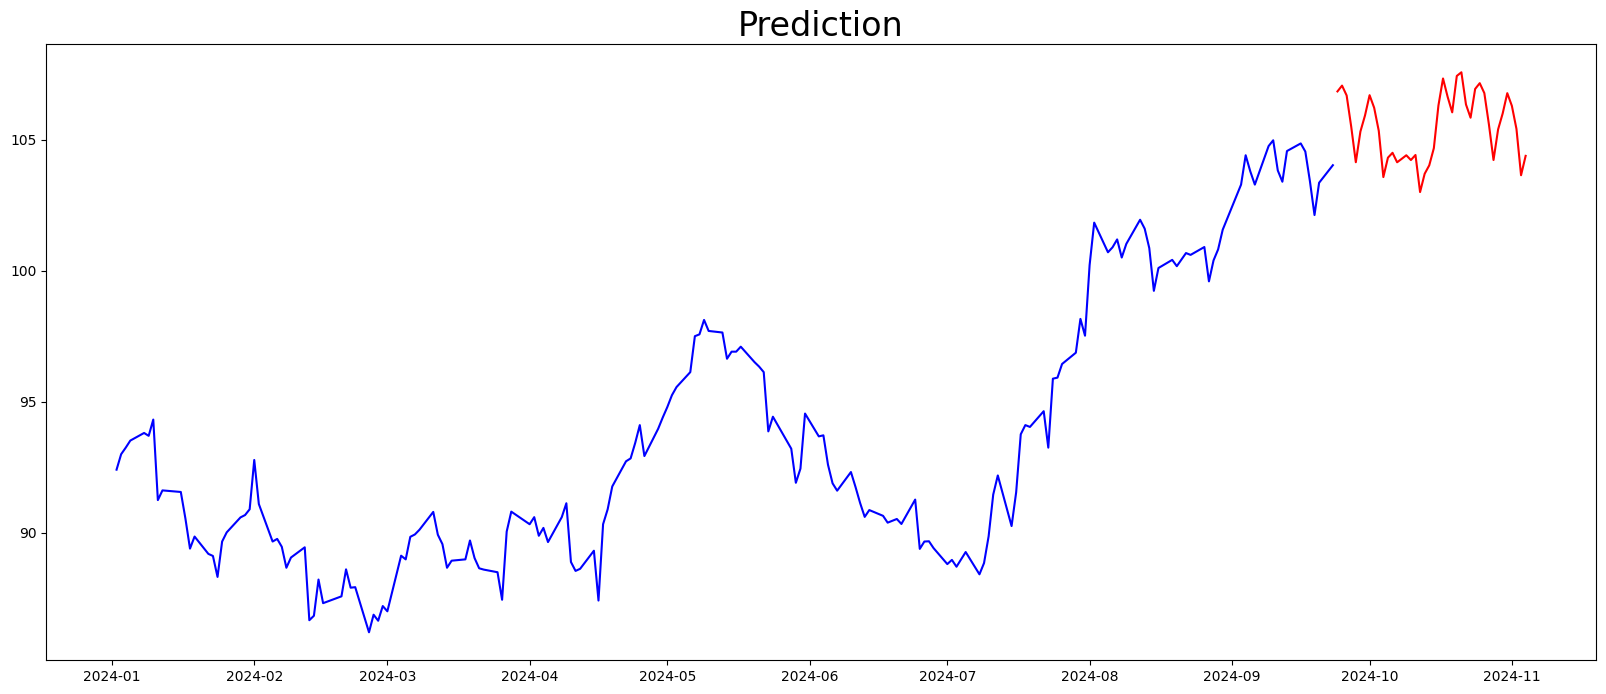

In [33]:
plt.rcParams['figure.figsize'] = (20,8)
plt.plot(pred, color = "red")
plt.plot(df_t['Close'],color="blue")
plt.title("Prediction", size = 24)

In [34]:
def predict_future_price(ticker_num: int) -> np.float64:
    df_t = df_train[df_train["Ticker"] == f"ticker_{ticker_num}"].copy()
    df_t.set_index("Date", inplace=True)
    df_t.index = pd.DatetimeIndex(df_t.index).to_period("D")

    p, d, q = 0, 1, 0
    
    best_model = SARIMAX(
        df_t["Close"],
        seasonal_order=(p, d, q, 30),
        simple_differencing=False
    )
    res = best_model.fit(disp=False)

    pred = res.predict(start="2024-09-24", end="2024-11-04")
    return pred.iloc[30]

In [35]:
predict_future_price(1)

106.92827367772693

In [36]:
df_train[(df_train["Ticker"] == "ticker_1") & (df_train["Date"] == "2024-09-23")]["Close"].iloc[0]

104.0199966430664

In [37]:
predictions = []

In [38]:
for i in tqdm(range(1, 5001)):
    try:
        future_close = predict_future_price(i)
        last_close = df_train[(df_train["Ticker"] == f"ticker_{i}") & (df_train["Date"] == "2024-09-23")]["Close"].iloc[0]
        if future_close > last_close:
            result = 1
        else:
            result = 0
    except IndexError: # Some stocks are gone by 2024.
        result = 0
    finally:
        predictions.append([f"ticker_{i}", result])

  0%|          | 0/5000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarn

In [39]:
df_submission = pd.DataFrame(predictions, columns=["ID", "Pred"])

In [40]:
df_submission

,ID,Pred
0,ticker_1,1
1,ticker_2,1
2,ticker_3,0
3,ticker_4,1
4,ticker_5,0
...,...,...
4995,ticker_4996,1
4996,ticker_4997,0
4997,ticker_4998,0
4998,ticker_4999,0


In [41]:
df_submission.describe()

,Pred
count,5000.00000
mean,0.61740
std,0.48607
min,0.00000
25%,0.00000
50%,1.00000
75%,1.00000
max,1.00000


In [42]:
df_submission.to_csv("submission.csv", index=False)